# RAG Benchmark – Results Analysis

This notebook builds a **per-question metrics DataFrame** from the benchmark outputs,
aggregates by configuration and by individual pipeline component (Chunker, Embedder, LLM),
and produces plots for the thesis.

**Expected input files in `evaluation/results/`**

| File | Created by |
|---|---|
| `evaluation_dataset.json` | `orchestration/benchmark_loop.py` |
| `per_question_scores.json` | `evaluation/ragas_eval.py` |

Run from the **project root** (default CWD in VS Code).

In [ ]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# ── Constants ──────────────────────────────────────────────────────────────
COMPONENTS    = ["Chunker", "Embedder", "LLM"]
RAGAS_METRICS = ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]
ALL_METRICS   = ["latency", "source_attribution"] + RAGAS_METRICS

METRIC_LABELS = {
    "faithfulness":       "Faithfulness",
    "answer_relevancy":   "Answer Relevancy",
    "context_recall":     "Context Recall",
    "context_precision":  "Context Precision",
    "source_attribution": "Source Attribution",
    "latency":            "Latency (s)",
}

## 1  Load raw data

In [ ]:
assert Path("../evaluation/results/evaluation_dataset.json").exists(), (
    f"Not found: ./evaluation/results/evaluation_dataset.json\nRun orchestration/benchmark_loop.py first."
)

with open("../evaluation/results/evaluation_dataset.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)

df_raw = pd.DataFrame(raw_data)

print(
    f"Loaded {len(df_raw):,} records  "
    f"| {df_raw['Configuration'].nunique()} configuration(s)  "
    f"| {df_raw['question_id'].nunique()} question(s)"
)
df_raw[["question_id", "Configuration", "latency", "prompt_tokens", "completion_tokens"]].head()

In [ ]:
# Compute source attribution directly from the raw data
df_raw["source_attribution"] = df_raw.apply(
    lambda r: 1.0 if str(r.get("expected_source", "")) in str(r.get("answer", "")) else 0.0,
    axis=1,
)

In [ ]:
# Initialise RAGAS columns as NaN; replace if per_question_scores.json exists
for m in RAGAS_METRICS:
    df_raw[m] = np.nan

if Path("../evaluation/results/per_question_scores.json").exists():
    df_ragas = pd.read_json("../evaluation/results/per_question_scores.json")
    available = [c for c in RAGAS_METRICS if c in df_ragas.columns]
    if available:
        df_raw = df_raw.drop(columns=available, errors="ignore")
        df_raw = df_raw.merge(
            df_ragas[["question_id", "Configuration"] + available].drop_duplicates(),
            on=["question_id", "Configuration"],
            how="left",
        )
        print(f"Merged RAGAS columns: {available}")
    else:
        print("per_question_scores.json found but contains no RAGAS metric columns.")
else:
    print(
        f"per_question_scores.json not found – RAGAS metrics are NaN.\n"
        f"Run: python evaluation/ragas_eval.py"
    )

# Working copy: drop large text fields not needed for analysis
df = df_raw.drop(columns=["contexts", "answer", "ground_truth"], errors="ignore").copy()

print(f"\nMaster DataFrame: {len(df)} rows × {len(df.columns)} columns")
df.dtypes

## 2  Per-question view

One row per (question × configuration).
This is the ground-truth dataset for all subsequent analysis.

In [ ]:
display_cols = (
    [c for c in ["question_id", "question", "Configuration", "Chunker", "Embedder", "LLM"] if c in df.columns]
    + [m for m in ALL_METRICS if m in df.columns]
)
df[display_cols].sort_values(["question_id", "Configuration"]).reset_index(drop=True)

In [ ]:
# Data-coverage check: every config should have the same number of questions
n_questions = df["question_id"].nunique()
n_configs   = df["Configuration"].nunique()
counts      = df.groupby("Configuration")["question_id"].count()

if counts.nunique() > 1:
    print("WARNING – unequal question counts per configuration:")
    print(counts[counts != n_questions].to_string())
else:
    print(f"OK – {n_configs} configurations × {n_questions} question(s) = {len(df)} rows")

# Missing values summary
metric_cols = [m for m in ALL_METRICS if m in df.columns]
missing     = df[metric_cols].isna().sum()
if missing.any():
    print("\nMissing values per metric:")
    print(missing[missing > 0].to_string())
else:
    print("\nNo missing metric values.")

## 3  Configuration-level leaderboard

Each row is the **mean across all questions** for that configuration.

In [ ]:
metric_cols = [m for m in ALL_METRICS if m in df.columns]

df_configs = (
    df.groupby(["Configuration", "Chunker", "Embedder", "LLM"])
    .agg(
        n_questions=("question_id", "count"),
        **{m: (m, "mean") for m in metric_cols},
    )
    .reset_index()
    .round(4)
)

# Composite quality score: mean of whichever RAGAS metrics are present
ragas_in_configs = [m for m in RAGAS_METRICS if m in df_configs.columns and df_configs[m].notna().any()]
if ragas_in_configs:
    df_configs["quality_score"] = df_configs[ragas_in_configs].mean(axis=1)
    df_configs = df_configs.sort_values("quality_score", ascending=False)
else:
    df_configs = df_configs.sort_values("source_attribution", ascending=False)

df_configs = df_configs.reset_index(drop=True)

df_configs.to_csv("../evaluation/results/config_leaderboard.csv", index=False, sep=";")
print(f"Saved config_leaderboard.csv  ({len(df_configs)} configurations)")
df_configs

## 4  Component-level analysis

For each pipeline dimension (Chunker, Embedder, LLM) we average over **all configurations
that share that component value** (9 configs per value in a full 3×3×3 design).
This gives the marginal effect of each choice, independent of the others.

In [ ]:
dfs_comp = {}
for comp in COMPONENTS:
    grp = (
        df.groupby(comp)
        .agg(
            n_samples=("question_id", "count"),
            **{m: (m, "mean") for m in metric_cols},
        )
        .reset_index()
        .round(4)
    )
    dfs_comp[comp] = grp
    grp.to_csv(f"../evaluation/results/component_{comp.lower()}.csv", index=False, sep=";")

for comp in COMPONENTS:
    print(f"\n{'=' * 60}")
    print(f"  By {comp}")
    print(f"{'=' * 60}")
    display(dfs_comp[comp])

## 5  Visualisations

In [19]:
sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = sns.color_palette("tab10")
METRIC_COLORS = {m: PALETTE[i] for i, m in enumerate(ALL_METRICS)}

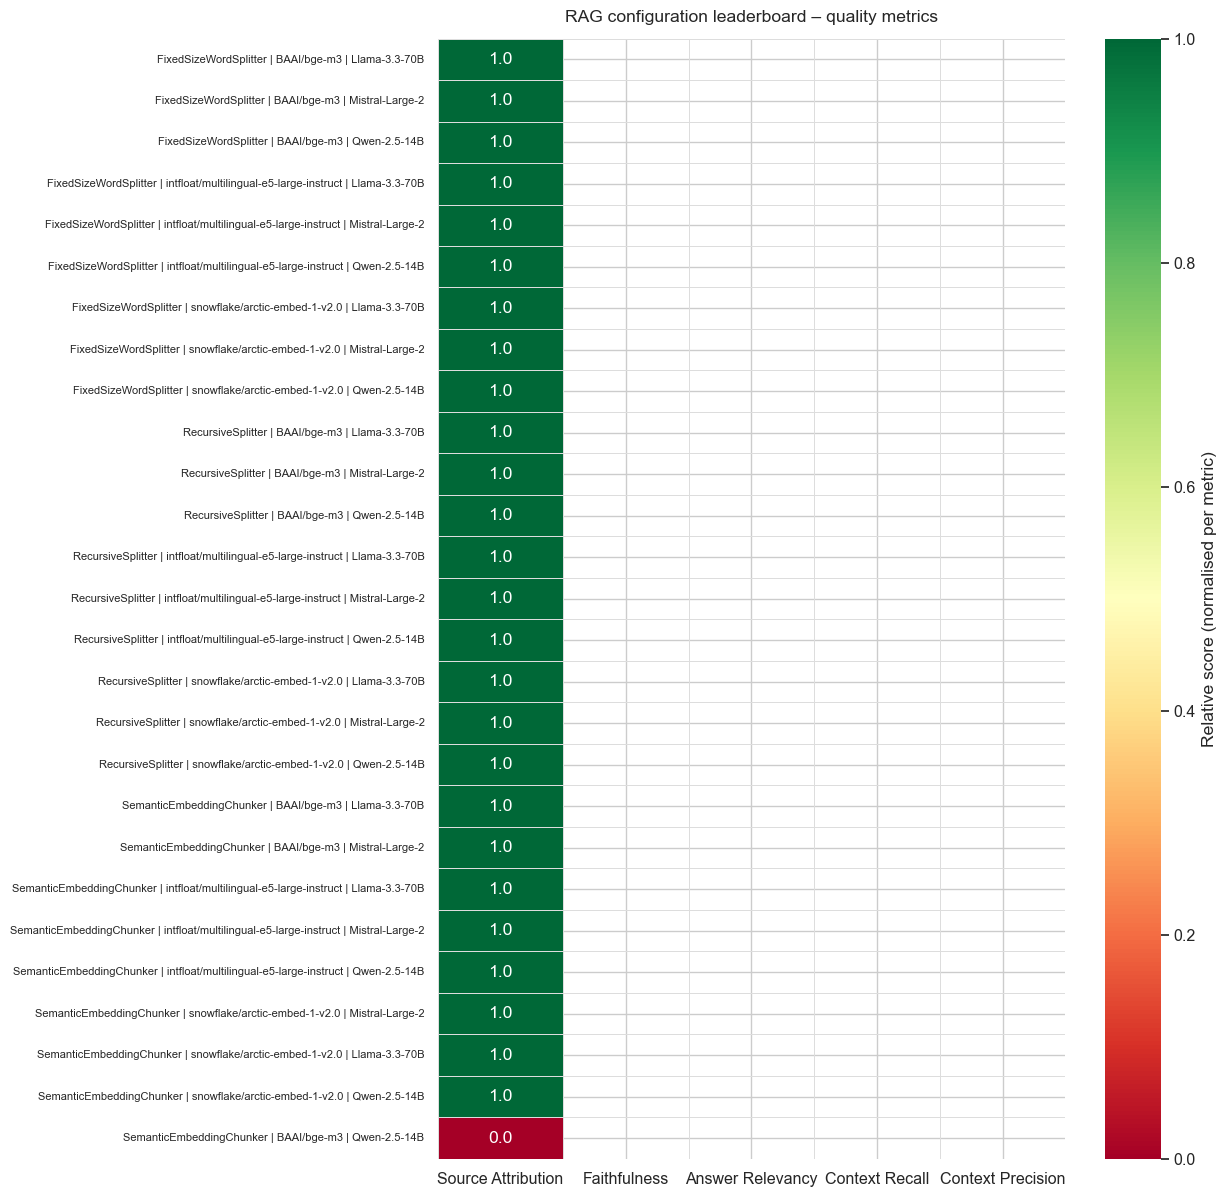

In [21]:
# ── 5a  Heatmap: configurations × quality + attribution metrics ──────────────
hm_metrics = ["source_attribution"] + [m for m in RAGAS_METRICS if m in df_configs.columns]

plot_data = df_configs.set_index("Configuration")[hm_metrics].copy()
plot_data.columns = [METRIC_LABELS.get(c, c) for c in hm_metrics]

normed = plot_data.apply(lambda col: (col - col.min()) / ((col.max() - col.min()) or 1))
annot  = plot_data.round(3).astype(str).replace("nan", "–")

fig, ax = plt.subplots(
    figsize=(max(8, 2.5 * len(hm_metrics)), max(6, 0.45 * len(df_configs)))
)
sns.heatmap(
    normed,
    annot=annot, fmt="",
    cmap="RdYlGn",
    linewidths=0.4, linecolor="#ddd",
    cbar_kws={"label": "Relative score (normalised per metric)"},
    ax=ax,
)
ax.set_title("RAG configuration leaderboard – quality metrics", pad=12)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("../evaluation/results/heatmap_configs.png", dpi=150, bbox_inches="tight")
plt.show()

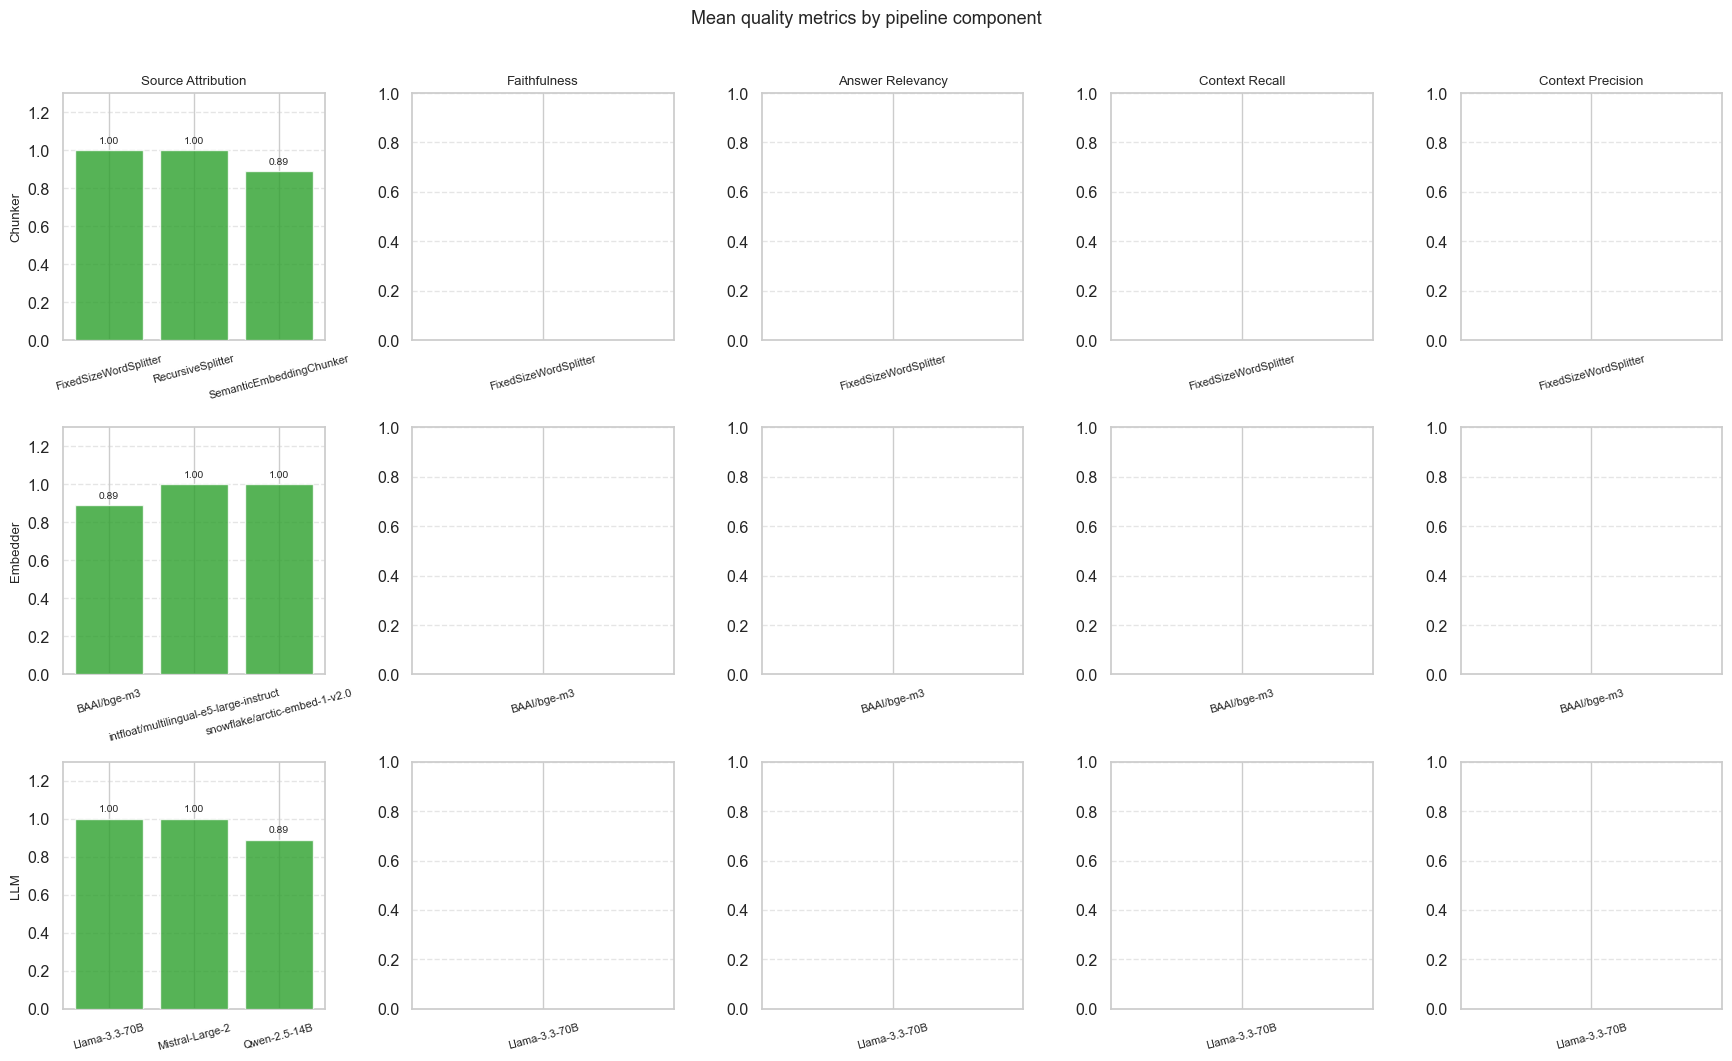

In [23]:
# ── 5b  Bar charts: each component × quality metrics ────────────────────────
quality_metrics = ["source_attribution"] + [m for m in RAGAS_METRICS if m in df.columns]
n_rows = len(COMPONENTS)
n_cols = len(quality_metrics)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(max(12, 3.5 * n_cols), 3.5 * n_rows),
    sharey=False,
)
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row_i, comp in enumerate(COMPONENTS):
    grp = dfs_comp[comp]
    for col_j, metric in enumerate(quality_metrics):
        ax    = axes[row_i, col_j]
        vals  = grp[metric]
        color = METRIC_COLORS.get(metric, "#4C72B0")
        bars  = ax.bar(grp[comp], vals, color=color, alpha=0.80, edgecolor="white", zorder=3)
        valid = vals.dropna()
        y_max = max(valid.max() * 1.30 if not valid.empty else 1.0, 0.05)
        ax.set_ylim(0, y_max)
        ax.set_title(METRIC_LABELS.get(metric, metric) if row_i == 0 else "", fontsize=9.5)
        if col_j == 0:
            ax.set_ylabel(comp, fontsize=9.5)
        ax.tick_params(axis="x", labelrotation=15, labelsize=8)
        ax.yaxis.grid(True, linestyle="--", alpha=0.5)
        ax.set_axisbelow(True)
        for bar, val in zip(bars, vals):
            if not pd.isna(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + y_max * 0.02,
                    f"{val:.2f}",
                    ha="center", va="bottom", fontsize=7.5,
                )

fig.suptitle("Mean quality metrics by pipeline component", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../evaluation/results/barplot_components_quality.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── 5c  Bar charts: each component × latency ────────────────────────────────
fig, axes = plt.subplots(
    1, len(COMPONENTS),
    figsize=(4.5 * len(COMPONENTS), 4.5),
    sharey=False,
)

for col_j, comp in enumerate(COMPONENTS):
    ax   = axes[col_j]
    grp  = dfs_comp[comp]
    vals = grp["latency"]
    color = METRIC_COLORS.get("latency", "#937860")
    bars  = ax.bar(grp[comp], vals, color=color, alpha=0.80, edgecolor="white", zorder=3)
    valid = vals.dropna()
    y_max = valid.max() * 1.30 if not valid.empty else 1.0
    ax.set_ylim(0, y_max)
    ax.set_title(comp, fontsize=10)
    ax.set_ylabel("Latency (s)" if col_j == 0 else "")
    ax.tick_params(axis="x", labelrotation=15, labelsize=8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    for bar, val in zip(bars, vals):
        if not pd.isna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + y_max * 0.02,
                f"{val:.2f}",
                ha="center", va="bottom", fontsize=7.5,
            )

fig.suptitle("Mean latency by pipeline component", fontsize=13)
plt.tight_layout()
plt.savefig("../evaluation/results/barplot_components_latency.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── 5d  Scatter: latency vs average quality ─────────────────────────────────
ragas_in_configs = [m for m in RAGAS_METRICS if m in df_configs.columns and df_configs[m].notna().any()]
if ragas_in_configs:
    df_configs["avg_quality"] = df_configs[ragas_in_configs].mean(axis=1)
    y_label = "Avg. RAGAS quality score"
else:
    df_configs["avg_quality"] = df_configs["source_attribution"]
    y_label = "Source Attribution"

llm_order  = sorted(df_configs["LLM"].unique())
llm_colors = {llm: PALETTE[i] for i, llm in enumerate(llm_order)}

fig, ax = plt.subplots(figsize=(7, 5))
for llm in llm_order:
    mask = df_configs["LLM"] == llm
    ax.scatter(
        df_configs.loc[mask, "latency"],
        df_configs.loc[mask, "avg_quality"],
        label=llm,
        color=llm_colors[llm],
        s=90, alpha=0.85, edgecolors="k", linewidths=0.4, zorder=3,
    )
ax.set_xlabel(METRIC_LABELS.get("latency", "latency"))
ax.set_ylabel(y_label)
ax.set_title("Latency vs Quality")
ax.legend(title="LLM", fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../evaluation/results/scatter_latency_quality.png", dpi=150, bbox_inches="tight")
plt.show()

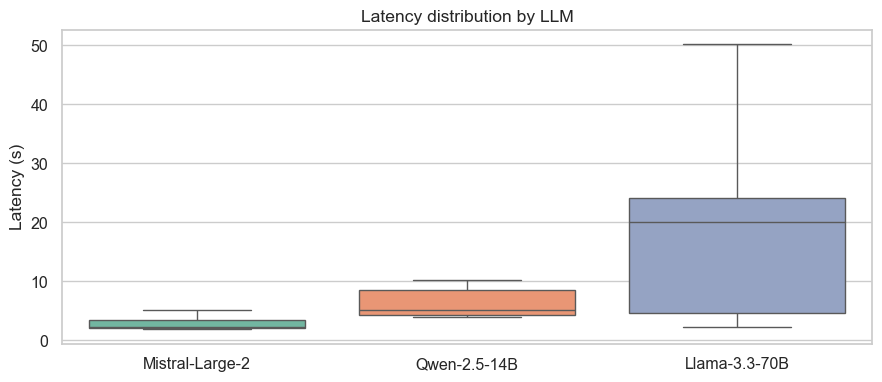

In [26]:
# ── 5e  Box plot: latency distribution by LLM ───────────────────────────────
order = df.groupby("LLM")["latency"].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df, x="LLM", y="latency", order=order, palette="Set2", ax=ax)
ax.set_title("Latency distribution by LLM")
ax.set_xlabel("")
ax.set_ylabel("Latency (s)")
plt.tight_layout()
plt.savefig("../evaluation/results/boxplot_latency_llm.png", dpi=150, bbox_inches="tight")
plt.show()

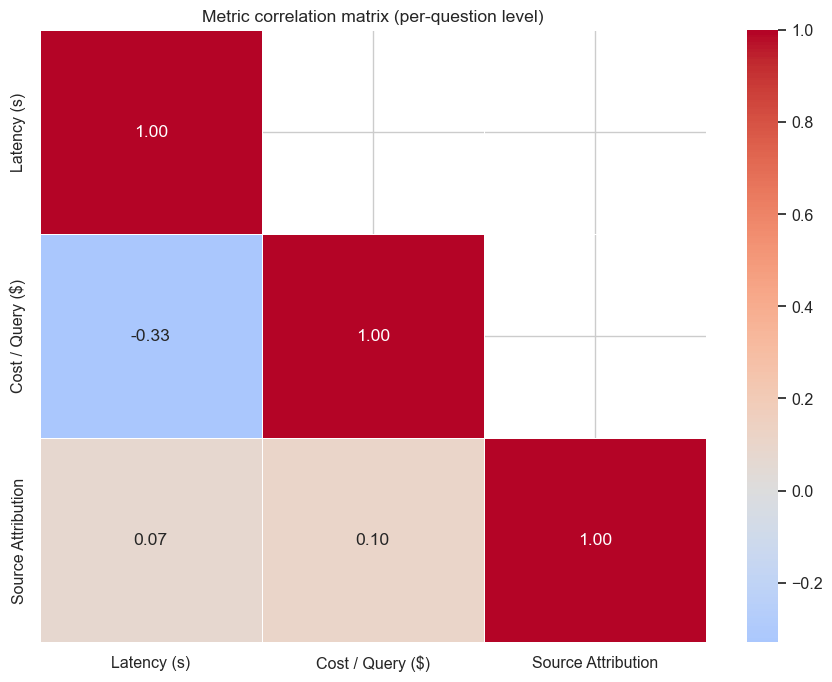

In [27]:
# ── 5f  Correlation matrix (per-question level) ──────────────────────────────
corr_cols = [m for m in ALL_METRICS if m in df.columns and df[m].notna().sum() >= 3]

if len(corr_cols) >= 2:
    corr   = df[corr_cols].corr()
    labels = [METRIC_LABELS.get(c, c) for c in corr_cols]
    mask   = np.triu(np.ones_like(corr, dtype=bool), k=1)

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(
        corr,
        annot=True, fmt=".2f",
        cmap="coolwarm", center=0,
        mask=mask,
        xticklabels=labels, yticklabels=labels,
        linewidths=0.5,
        ax=ax,
    )
    ax.set_title("Metric correlation matrix (per-question level)")
    plt.tight_layout()
    plt.savefig("../evaluation/results/correlation_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Not enough non-NaN metric columns for a correlation matrix yet.")

## 6  Export combined per-question CSV

One row per (question × configuration) with every computed metric.

In [ ]:
export_cols = (
    [c for c in ["question_id", "question", "Chunker", "Embedder", "LLM", "Configuration"] if c in df_raw.columns]
    + [m for m in ALL_METRICS if m in df_raw.columns]
)
df_export = df_raw[export_cols].copy().round(6)

export_path = "../evaluation/results/per_question_all_metrics.csv"
df_export.to_csv(export_path, index=False, sep=";")
print(f"Saved {len(df_export)} rows to {export_path}")
df_export